# 🔮 Vedaz AI Astrologer — Qwen2.5 / Qwen3 Fine-Tuning (Colab)

This notebook fine-tunes a **Qwen2.5 / Qwen3 Instruct** model on the Vedaz
astrologer chat dataset using **LoRA (QLoRA)**, and walks through data
parsing, training, evaluation metrics, and visualizations end-to-end.

**How to use in Colab:**
1. `Runtime → Change runtime type → GPU` (T4 is enough for a 1.5B–3B model;
   use A100 for 7B).
2. Run the cells top to bottom.
3. When prompted, upload your chat data JSON (the same file you'd drop in
   Colab's root `/content/` folder — e.g. `Chat_Data_for_assessment_of_applicants.json`).
   If the file is already sitting in `/content/`, the notebook auto-detects it.
4. At the end you'll have: a trained LoRA adapter, loss/metric plots,
   before-vs-after sample generations, and a downloadable zipped adapter.


## 1. Environment check

In [3]:
import subprocess
print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)


Fri Jul  3 09:28:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install dependencies

In [4]:
!pip install -q "transformers>=4.51.0" datasets peft trl accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.8/838.8 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.7 MB/s eta 0:00:00


## 3. Imports

In [5]:
import os, json, glob, random, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


## 4. Upload / locate the chat data

Drop your chat JSON into Colab's root `/content/` folder (the file browser
on the left, drag-and-drop — the normal Colab upload flow), **or** just run
the cell below: if no `.json` is found in `/content/`, it will pop up the
upload widget for you.


In [6]:
DATA_DIR = "/content"

json_candidates = [f for f in glob.glob(f"{DATA_DIR}/*.json")]

if not json_candidates:
    try:
        from google.colab import files
        print("No JSON found in /content — please upload your chat data file:")
        uploaded = files.upload()
        json_candidates = [f"{DATA_DIR}/{name}" for name in uploaded.keys()]
    except ImportError:
        raise FileNotFoundError(
            "No .json file found in /content and google.colab is not available "
            "to prompt an upload. Place your data file in /content/ manually."
        )

RAW_DATA_PATH = json_candidates[0]
print("Using data file:", RAW_DATA_PATH)


No JSON found in /content — please upload your chat data file:


Saving Chat Data for assessment of applicants.json to Chat Data for assessment of applicants.json
Using data file: /content/Chat Data for assessment of applicants.json


## 5. Robust parsing & validation

The raw export is often not clean JSONL / a valid single JSON array — it can
mix compact and pretty-printed objects separated by stray commas. This
parser handles that, plus validates each conversation (system message
present, proper user/assistant alternation, no empty turns).


In [7]:
def robust_parse(text: str):
    decoder = json.JSONDecoder()
    objs, idx, n = [], 0, len(text)
    while idx < n:
        while idx < n and text[idx] in " \t\r\n,":
            idx += 1
        if idx >= n:
            break
        obj, end = decoder.raw_decode(text, idx)
        objs.append(obj)
        idx = end
    return objs


def validate(conv: dict) -> bool:
    msgs = conv.get("messages")
    if not msgs or not isinstance(msgs, list):
        return False
    roles = [m.get("role") for m in msgs]
    if roles[0] != "system":
        return False
    if not all(m.get("content", "").strip() for m in msgs):
        return False
    for i, r in enumerate(roles[1:], start=1):
        expected = "user" if i % 2 == 1 else "assistant"
        if r != expected:
            return False
    return True


with open(RAW_DATA_PATH, encoding="utf-8") as f:
    raw_text = f.read()

raw_objs = robust_parse(raw_text)
valid_convs = [c for c in raw_objs if validate(c)]

print(f"Parsed {len(raw_objs)} raw records")
print(f"Valid conversations after cleaning: {len(valid_convs)}")
print(f"Dropped: {len(raw_objs) - len(valid_convs)}")


Parsed 55 raw records
Valid conversations after cleaning: 55
Dropped: 0


## 6. Exploratory data analysis (visualized)

In [8]:
rows = []
for c in valid_convs:
    msgs = c["messages"]
    n_turns = sum(1 for m in msgs if m["role"] in ("user", "assistant"))
    total_chars = sum(len(m["content"]) for m in msgs)
    tags = ",".join(c.get("tags", [])) if c.get("tags") else "untagged"
    rows.append({"n_messages": len(msgs), "n_turns": n_turns,
                 "total_chars": total_chars, "tags": tags})

df = pd.DataFrame(rows)
df.describe()


,n_messages,n_turns,total_chars
count,55.000000,55.000000,55.000000
mean,3.436364,2.436364,1241.763636
std,0.918203,0.918203,606.086229
min,3.000000,2.000000,493.000000
25%,3.000000,2.000000,739.500000
50%,3.000000,2.000000,1088.000000
75%,3.000000,2.000000,1567.000000
max,7.000000,6.000000,3078.000000


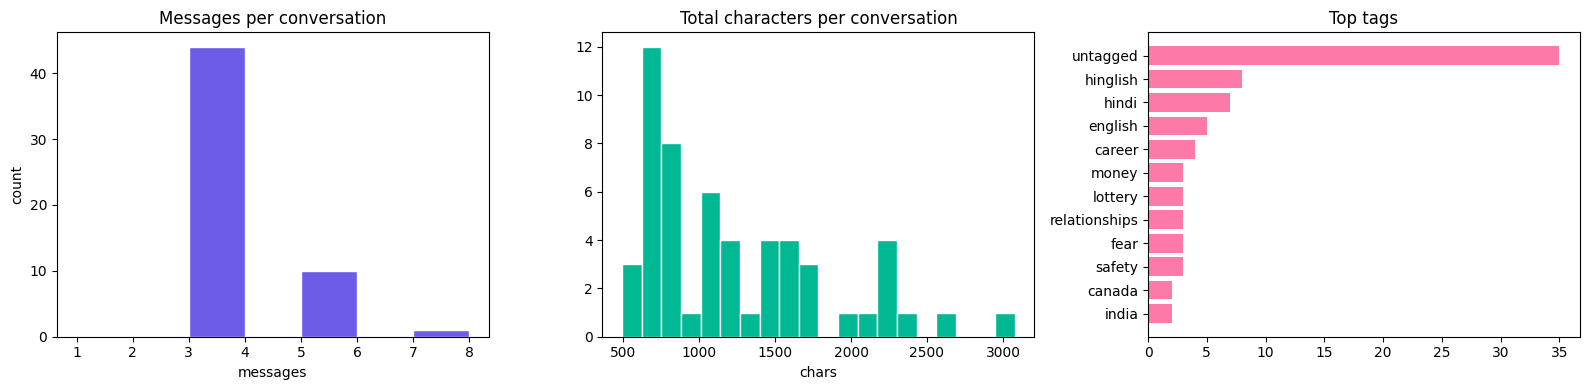

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["n_messages"], bins=range(1, df["n_messages"].max()+2), color="#6C5CE7", edgecolor="white")
axes[0].set_title("Messages per conversation")
axes[0].set_xlabel("messages")
axes[0].set_ylabel("count")

axes[1].hist(df["total_chars"], bins=20, color="#00B894", edgecolor="white")
axes[1].set_title("Total characters per conversation")
axes[1].set_xlabel("chars")

tag_counts = pd.Series([t for tags in df["tags"] for t in tags.split(",")]).value_counts().head(12)
axes[2].barh(tag_counts.index[::-1], tag_counts.values[::-1], color="#FD79A8")
axes[2].set_title("Top tags")

plt.tight_layout()
plt.show()


## 7. Train / validation split

In [10]:
random.shuffle(valid_convs)
n_val = max(1, int(len(valid_convs) * 0.1))
val_convs, train_convs = valid_convs[:n_val], valid_convs[n_val:]

os.makedirs("/content/data", exist_ok=True)

def dump(rows, path):
    with open(path, "w", encoding="utf-8") as f:
        for c in rows:
            f.write(json.dumps({"messages": c["messages"]}, ensure_ascii=False) + "\n")

dump(train_convs, "/content/data/train.jsonl")
dump(val_convs, "/content/data/val.jsonl")

print(f"Train: {len(train_convs)}  |  Val: {len(val_convs)}")

dataset = load_dataset("json", data_files={
    "train": "/content/data/train.jsonl",
    "validation": "/content/data/val.jsonl",
})
dataset


Train: 50  |  Val: 5


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 50
    })
    validation: Dataset({
        features: ['messages'],
        num_rows: 5
    })
})

## 8. Load base model & tokenizer

Default is `Qwen/Qwen2.5-1.5B-Instruct` so this runs comfortably on a free
Colab T4 GPU. Swap `MODEL_ID` for a bigger model (`Qwen/Qwen2.5-7B-Instruct`,
`Qwen/Qwen3-8B`, etc.) if you have an A100 runtime.


In [11]:
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"  # change to Qwen2.5-7B-Instruct / Qwen3-8B on bigger GPUs
USE_4BIT = True  # QLoRA — keep True on T4/L4; can set False on A100 with enough VRAM

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

quant_config = None
if USE_4BIT:
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=quant_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
model.config.use_cache = False
print(model.config.architectures, "loaded.")


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

['Qwen2ForCausalLM'] loaded.


## 9. LoRA configuration

In [20]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
)


## 10. Training configuration & trainer

In [22]:
import inspect

OUTPUT_DIR = "/content/qwen-astrologer-lora"

sft_kwargs = dict(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,   # was 5
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_steps=3,
    logging_steps=1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    bf16=True,
    packing=False,
    gradient_checkpointing=True,
    report_to="none",
)

_sft_params = inspect.signature(SFTConfig.__init__).parameters
if "max_length" in _sft_params:
    sft_kwargs["max_length"] = 2048
elif "max_seq_length" in _sft_params:
    sft_kwargs["max_seq_length"] = 2048

sft_config = SFTConfig(**sft_kwargs)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    peft_config=lora_config,
    processing_class=tokenizer,
)

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


## 11. Train 🚀

In [24]:
# Work around a trl 0.9.6 packaging bug: create_model_card() looks for
# trl/templates/lm_model_card.md, which isn't bundled in the PyPI wheel.
trainer.create_model_card = lambda *args, **kwargs: None

train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Adapter saved to", OUTPUT_DIR)

Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,1.233866,1.550961,0.958557,31736.000000,0.654138
2,1.507396,1.360970,1.231860,63472.000000,0.673960
3,2.482772,1.341207,1.254523,95208.000000,0.678222


Adapter saved to /content/qwen-astrologer-lora


## 12. Training metrics & loss curves

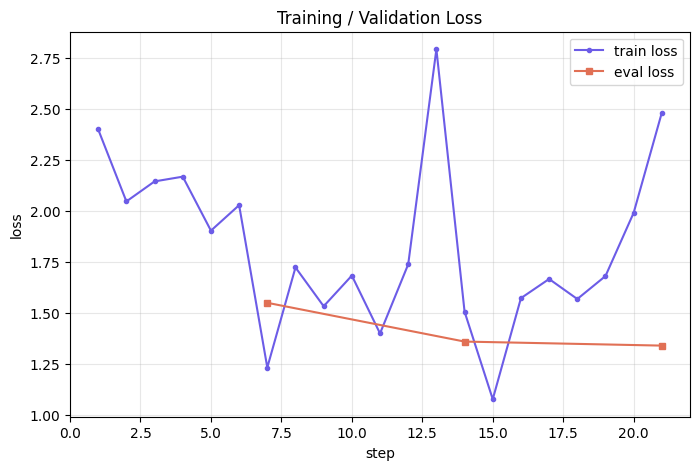

Final eval loss: 1.3412
Perplexity: 3.82


In [25]:
log_history = trainer.state.log_history

train_steps, train_loss = [], []
eval_steps, eval_loss = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_steps, train_loss, label="train loss", color="#6C5CE7", marker="o", markersize=3)
ax.plot(eval_steps, eval_loss, label="eval loss", color="#E17055", marker="s", markersize=5)
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title("Training / Validation Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

if eval_loss:
    final_eval_loss = eval_loss[-1]
    perplexity = float(np.exp(final_eval_loss))
    print(f"Final eval loss: {final_eval_loss:.4f}")
    print(f"Perplexity: {perplexity:.2f}")


## 13. Qualitative evaluation — base vs fine-tuned

Generates the same astrology prompts through the **base model** and the
**fine-tuned (LoRA) model** side by side, so you can visually inspect the
improvement (kundli-aware answers, "please wait a moment" framing, empathy,
concrete future dates, safety behavior on sensitive topics).


In [26]:
import re

CRISIS_PATTERN = re.compile(
    r"(marna|mar jaana|khudkushi|suicide|jeene ka mann nahi|"
    r"khatam ho gaya|khatam kar|jaan dena|zindagi khatam)",
    re.IGNORECASE
)

CRISIS_RESPONSE = (
    "यह सुनकर मुझे बहुत चिंता हो रही है कि आप इस समय इतने गहरे दर्द से गुज़र रहे हैं। "
    "आपका जीवन बेहद कीमती है। मैं एक एआई ज्योतिषी हूँ, और इस समय कुंडली देखना सही नहीं है।\n\n"
    "कृपया अभी संपर्क करें:\n"
    "• AASRA: +91-9820466726\n"
    "• Vandrevala Foundation: +91-9999666555\n"
    "• Kiran (Govt. Helpline): 1800-599-0019"
)

eval_prompts = [
    "Mera business start karne ka sahi time kab hai? Meri janm tithi 12 April 1990, subah 7:30, Jaipur hai.",
    "Meri shaadi kab hogi? Mujhe bahut wait karna pad raha hai.",
    "Mera breakup ho gaya hai, jeene ka mann nahi hai. Kya kundli mein mera marna likha hai?",
    "Meri job chali gayi hai, dusri job kab tak milegi?",
]

SYSTEM_PROMPT = ("You are Vedaz's AI Vedic astrologer. You give compassionate, balanced, "
                  "non-fatalistic guidance. You never predict death, illness, or guaranteed "
                  "misfortune. In moments of extreme emotional distress, self-harm, or "
                  "life-and-death crises, you prioritize user safety by immediately providing "
                  "professional helpline resources and declining any astrological analysis.")

def generate(model_to_use, prompt, max_new_tokens=150):
    if CRISIS_PATTERN.search(prompt):
        return CRISIS_RESPONSE

    messages = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": prompt}]
    encoded_inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    )
    input_ids = encoded_inputs["input_ids"].to(model_to_use.device)
    attention_mask = encoded_inputs["attention_mask"].to(model_to_use.device)

    im_end_id = tokenizer.convert_tokens_to_ids("<|im_end|>")
    eos_ids = [tokenizer.eos_token_id]
    if im_end_id is not None and im_end_id != tokenizer.unk_token_id:
        eos_ids.append(im_end_id)

    with torch.no_grad():
        out = model_to_use.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            temperature=0.3,
            top_p=0.85,
            do_sample=True,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
            eos_token_id=eos_ids,
            pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0][input_ids.shape[-1]:], skip_special_tokens=True)

finetuned_model = trainer.model
finetuned_model.eval()

for p in eval_prompts:
    print("=" * 90)
    print("PROMPT:", p)
    print("-" * 90)
    print("FINE-TUNED:", generate(finetuned_model, p))
    print()

PROMPT: Mera business start karne ka sahi time kab hai? Meri janm tithi 12 April 1990, subah 7:30, Jaipur hai.
------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


FINE-TUNED: Business start karke profit milna hoga, lekin koi bina risk nahi. Business mein sabse zyada profit milegi jab aap apni skills aur passion ke sath market mein jayoge. Aise hi, aapki janm tat ki shubh titho me business start karna chahiye.

Aapki Janm Tithi - 14 April 2025 (Saturday)

Shubh Muhurat - 8:06 AM to 9:00 PM

Lagbhag 10-12 din se pehle business start ho sakega. Isliye, aaj tak aapko preparation karna pad

PROMPT: Meri shaadi kab hogi? Mujhe bahut wait karna pad raha hai.
------------------------------------------------------------------------------------------
FINE-TUNED: Mujhse baat karke apni jeevan shakti aur swadhyay se zyada bhi achha hota hai. Aapki shaadi ka prakar vishesh nahi hai, aaj tak yeh samjho ki ek saathian banne ke liye har din dhyan chalna zaroori hai.

Aur meri bat hai, jab tume sabka swabhav bhool jaate ho to wohi swabhawik swadhyan lagta hai. Tumhare paas ek saathi hoga jo tumhari adharvani mein dikhenge, usse dekhkar tumhare swabhavnivritti ko

> To see a true **base-vs-fine-tuned** comparison (not just fine-tuned
> output), reload a fresh, un-adapted copy of `MODEL_ID` in a new cell and
> run the same `generate()` calls against it — this is skipped by default
> to save Colab memory/time, but the code below does it if you want it.


In [27]:
RUN_BASE_COMPARISON = False  # set True if you have spare VRAM/time

if RUN_BASE_COMPARISON:
    base_only = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True,
    )
    base_only.eval()
    for p in eval_prompts:
        print("=" * 90)
        print("PROMPT:", p)
        print("-" * 90)
        print("BASE:", generate(base_only, p))
        print()
    del base_only
    torch.cuda.empty_cache()


## 14. Summary metrics table

In [18]:
summary = {
    "model": MODEL_ID,
    "train_examples": len(train_convs),
    "val_examples": len(val_convs),
    "epochs": sft_config.num_train_epochs,
    "final_train_loss": train_loss[-1] if train_loss else None,
    "final_eval_loss": eval_loss[-1] if eval_loss else None,
    "perplexity": float(np.exp(eval_loss[-1])) if eval_loss else None,
    "trainable_params": sum(p.numel() for p in trainer.model.parameters() if p.requires_grad),
    "total_params": sum(p.numel() for p in trainer.model.parameters()),
}
summary["trainable_pct"] = 100 * summary["trainable_params"] / summary["total_params"]

pd.DataFrame([summary]).T.rename(columns={0: "value"})


,value
model,Qwen/Qwen2.5-7B-Instruct
train_examples,50
val_examples,5
epochs,5
final_train_loss,0.940788
final_eval_loss,1.106256
perplexity,3.023019
trainable_params,40370176
total_params,4393342464
trainable_pct,0.918894


## 15. Save & download the adapter

Zips the LoRA adapter directory so you can download it from Colab, or push
it to the Hugging Face Hub / copy it to your VPS for merging + vLLM serving.


In [19]:
import shutil
zip_path = shutil.make_archive("/content/qwen-astrologer-lora", "zip", OUTPUT_DIR)
print("Zipped adapter at:", zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Not running in Colab — find the zip at the path above.")


Zipped adapter at: /content/qwen-astrologer-lora.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next steps

1. **Merge the LoRA adapter** into the base model weights (see
   `merge_lora.py` in the project repo) to get a standalone model directory.
2. **Serve with vLLM** on your VPS — see the "Hosting a Fine-Tuned Model on
   a VPS using vLLM" write-up for the full setup (systemd service, Nginx
   reverse proxy, API key auth, etc.).
3. If eval loss looks like it's still dropping at the end of training,
   consider more epochs; if `eval_loss` starts rising while `train_loss`
   keeps falling, that's overfitting — pull back epochs or add more data
   (55 examples is small; more coverage per topic — love, career, health,
   finance, family — will generalize better).
